In [20]:
!cd ../ && bash env.sh 
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys 
import scanpy as sc
import warnings
import scanpy as sc
import anndata as ad
import os
from scipy.sparse import issparse
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
plt.rcParams["font.family"] = "Arial"
main_dir = '../'
# task_grn_inference_dir = '../../'
output_dir = f"{main_dir}/output/"

# - local imports 
from hiara import retrieve_feature_data, retrieve_sig_stats

from hiara import PRIOR_DIR, PLOTS_DIR, CLOCKS_DIR,  CELL_TYPES, surrogate_names, colors_blind, palette_cell_types, palette_datasets, palette_datasets_pretty, palette_genders, AGING_COHORTS
from hiara import retrieve_adata, retrieve_net, retrieve_net_consensus
from hiara import clock_version, use_local_clocks, get_config
from grn_benchmark.src.helper import load_env
env = load_env()
TASK_GRN_INFERENCE_DIR = env['TASK_GRN_INFERENCE_DIR']
to_save = f'{PLOTS_DIR}/umap/'
os.makedirs(to_save, exist_ok=True)

bash: env.sh: No such file or directory


In [52]:
resolution = 10
cell_count_t = 2
# markers = {
#     "naive": ["CCR7", "SELL", "TCF7", "LEF1", "IL7R", "LTB"],
#     "central_memory": ["CCR7", "SELL", "IL7R", "CD27", "CD28", "TCF7"],
#     "effector_memory": ["GZMK", "IFNG", "NKG7", "CCL5", "CXCR3"],
#     "effector": ["GZMB", "PRF1", "GNLY", "NKG7", "KLRG1", "ZEB2"],
#     "temra": ["GZMB", "PRF1", "GNLY", "KLRD1", "KLRG1"],
#     "exhausted": ["PDCD1", "LAG3", "HAVCR2", "TIGIT", "TOX"]
# }

markers = {
    'naive' : ["CCR7", "SELL", "TCF7", "LEF1", "LTB"],
    'memory' : ["IL7R", "CD27", "CD28", "GZMK", "CCL5"],
    'effector' : ["GZMB", "PRF1", "GNLY", "KLRG1", "KLRD1"]
}

dataset = 'abf300' # 'CXCL9'
cell_type = 'CD8T'

# net = retrieve_net_consensus(cell_type=cell_type, min_degree=2)
adata_o = retrieve_adata(dataset=dataset, data_type='sc', cell_type=cell_type)

Retrieving consensus GRN for CD8T with min degree 2


In [53]:
if True:
    adata_full = adata_o[adata_o.obs['age']<40]
    donor_age = adata_full.obs['donor_age'].unique()[1]
    adata_full = adata_full[adata_full.obs['donor_age'] == donor_age].copy()
else:
    donor = adata_o.obs['donor_id'].unique()[0]
    # adata_full = adata_full[(adata_full.obs['condition'].isin(['24 h LPS']))].copy()
    adata_full = adata_o[adata_o.obs['donor_id'] == donor].copy()

In [54]:
adata_full

AnnData object with n_obs × n_vars = 920 × 12865
    obs: 'dataset', 'donor_id', 'age', 'sex', 'batch_info', 'ct_major_published', 'donor_age', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'Major_CT', 'Sub_CT', 'cell_type', 'condition'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'n_counts'
    uns: 'log1p'

In [55]:
import decoupler as dc
from task_grn_inference import normalize_func, bulkify_func

def cluster(adata):
    pseudobulk_group = get_config(dataset).pseudobulk_group
    print(f"Pseudobulk groups: {pseudobulk_group}")
    if 'leiden' in adata.obs:
        del adata.obs['leiden']
    adata.obs['group_id'] = adata.obs[pseudobulk_group].astype(str).agg('_'.join, axis=1)
    unique_groups = adata.obs['group_id'].unique()
    print(f"Number of unique groups: {len(unique_groups)}")
    adata.obs['leiden'] = 'unassigned'
    for group_id in unique_groups:
        group_mask = adata.obs['group_id'] == group_id
        adata_group = adata[group_mask].copy()    
        adata_group = normalize_func(adata_group)
        assert adata_group.n_obs > 100, f"Not enough cells in group {group_id} to perform clustering."
        sc.pp.neighbors(adata_group)
        sc.tl.leiden(adata_group, resolution=resolution)
        cluster_labels = [f"{group_id}_cluster_{c}" for c in adata_group.obs['leiden']]
        adata.obs.loc[group_mask, 'leiden'] = cluster_labels
    assert (adata.obs['leiden']== 'unassigned').sum()==0, "Some cells were not assigned a leiden cluster."
    adata.obs['leiden'] = pd.Categorical(adata.obs['leiden'])

    adata_cluster = bulkify_func(adata, covariates=['leiden'], cell_count_t=cell_count_t)
    adata_cluster = normalize_func(adata_cluster)
    adata_cluster.obs['leiden'] = pd.Categorical(adata_cluster.obs['leiden'])
    return adata_cluster

def annotate(adata):
    for subtype, genes in markers.items():
        sc.tl.score_genes(adata, gene_list=genes, score_name=f'{subtype}_score')
    
    print(f"Available genes per subtype:")
    for subtype, genes in markers.items():
        available = [g for g in genes if g in adata.var_names]
        print(f"{subtype}: {available}")

def dpt(adata):
    unique_groups = adata.obs['group_id'].unique()
    adata.obs['dpt'] = 'unassigned'
    for group in unique_groups:
        adata_sub = adata[adata.obs['group_id'] == group].copy()
        sc.pp.neighbors(adata_sub)
        root_cell = adata_sub.obs['naive_score'].idxmax()
        adata_sub.uns['iroot'] = np.where(adata_sub.obs_names == root_cell)[0][0]
        sc.tl.diffmap(adata_sub)
        sc.tl.dpt(adata_sub)
        adata.obs.loc[adata_sub.obs_names, 'dpt'] = adata_sub.obs['dpt_pseudotime']
    assert (adata.obs['dpt']== 'unassigned').sum()==0, "Some cells were not assigned a leiden cluster."

adata_cluster = cluster(adata_full)
annotate(adata_cluster)
dpt(adata_cluster)
dc.mt.ulm(adata_cluster, net=net, tmin=5)

Pseudobulk groups: ['donor_id', 'cell_type', 'age']
Number of unique groups: 1


Available genes per subtype:
naive: ['CCR7', 'SELL', 'TCF7', 'LEF1', 'LTB']
memory: ['IL7R', 'CD27', 'CD28', 'GZMK', 'CCL5']
effector: ['GZMB', 'PRF1', 'GNLY', 'KLRG1', 'KLRD1']


... storing 'donor_age' as categorical
... storing 'dataset' as categorical
... storing 'condition' as categorical
... storing 'group_id' as categorical


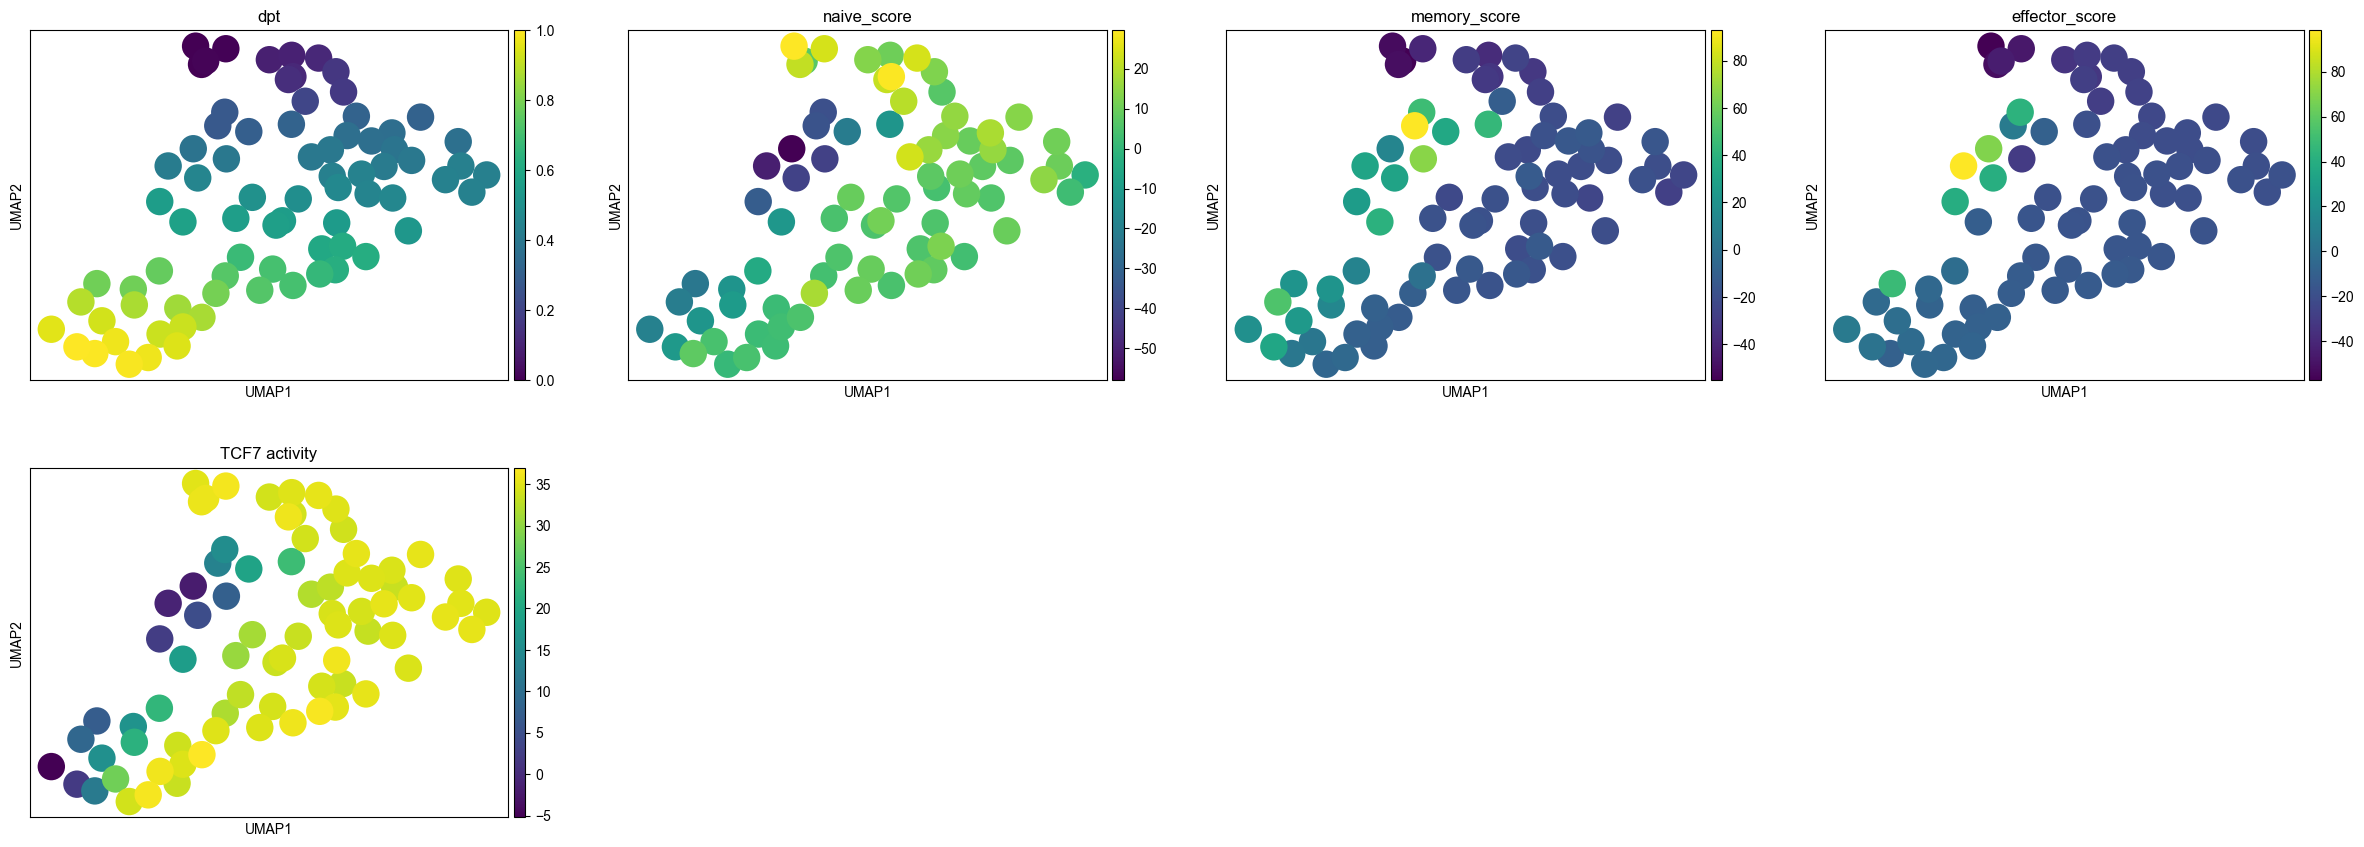

In [56]:
tf = 'TCF7'
# only show for one group condition
unique_groups = adata_cluster.obs['group_id'].unique()
adata_plot = adata_cluster[adata_cluster.obs['group_id'] == unique_groups[0]]
assert tf in adata_plot.obsm['score_ulm'].columns, f"{tf} not found in ULM scores."
adata_plot.obs[f'{tf} activity'] = adata_plot.obsm['score_ulm'][tf]
sc.pp.neighbors(adata_plot, n_neighbors=15)
sc.tl.umap(adata_plot)
sc.pl.umap(adata_plot, color=['dpt'] + [f'{subtype}_score' for subtype in markers.keys()] + [f'{tf} activity'])

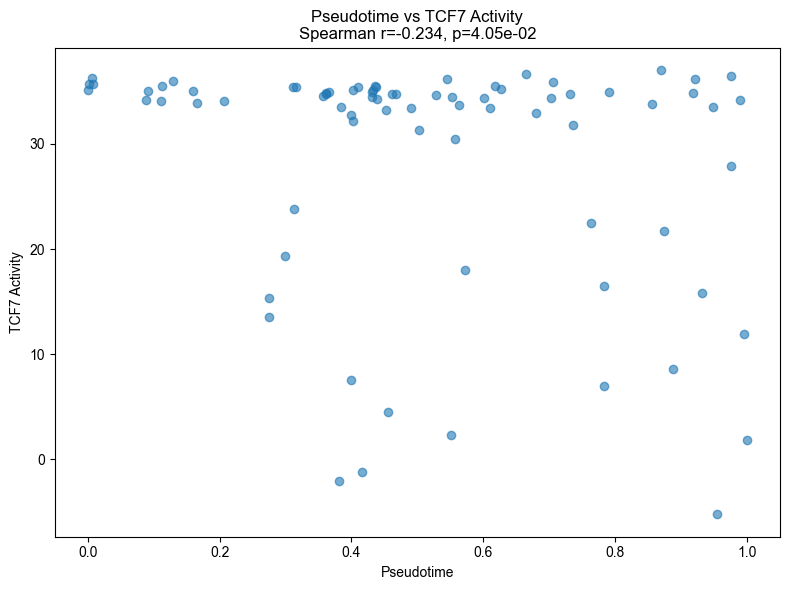

Spearman correlation: -0.234
P-value: 4.05e-02


In [57]:
from scipy.stats import spearmanr

# Display pseudotime and TF activity in a scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(adata_plot.obs['dpt'], adata_plot.obs[f'{tf} activity'], alpha=0.6)

# Calculate Spearman correlation
corr, pval = spearmanr(adata_plot.obs['dpt'], adata_plot.obs[f'{tf} activity'])

ax.set_xlabel('Pseudotime')
ax.set_ylabel(f'{tf} Activity')
ax.set_title(f'Pseudotime vs {tf} Activity\nSpearman r={corr:.3f}, p={pval:.2e}')
plt.tight_layout()
plt.show()

print(f'Spearman correlation: {corr:.3f}')
print(f'P-value: {pval:.2e}')